# **Klasifikasi Kualitas Udara**

**Description** : 

**Dataset** : https://www.kaggle.com/datasets/senadu34/air-quality-index-in-jakarta-2010-2021

**Model** : 

# **Data Loading**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns
import os

In [2]:
file_path = "/kaggle/input/air-quality-index-in-jakarta-2010-2021/ispu_dki_all.csv"
df = pd.read_csv(file_path)
df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),60.0,NaN,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),32.0,NaN,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),27.0,NaN,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),22.0,NaN,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),25.0,NaN,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


# Exploratory Data Analysis (EDA)

## Deskripsi Variabel

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4626 entries, 0 to 4625
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   4626 non-null   object 
 1   stasiun   4626 non-null   object 
 2   pm10      4466 non-null   float64
 3   pm25      723 non-null    float64
 4   so2       4607 non-null   float64
 5   co        4618 non-null   float64
 6   o3        4621 non-null   float64
 7   no2       4618 non-null   float64
 8   max       4626 non-null   float64
 9   critical  4625 non-null   object 
 10  categori  4626 non-null   object 
dtypes: float64(7), object(4)
memory usage: 397.7+ KB


In [4]:
df.describe()

,pm10,pm25,so2,co,o3,no2,max
count,4466.000000,723.000000,4607.000000,4618.000000,4621.000000,4618.000000,4626.000000
mean,65.086879,94.374827,28.183851,30.263534,86.586670,18.120832,99.432123
std,19.243150,27.427553,13.822107,13.640344,50.295879,8.451605,43.284775
min,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.000000,76.000000,18.000000,21.000000,51.000000,13.000000,70.000000
50%,64.000000,94.000000,27.000000,29.000000,78.000000,17.000000,91.000000
75%,75.000000,111.000000,34.000000,37.000000,110.000000,21.000000,118.000000
max,179.000000,287.000000,126.000000,134.000000,314.000000,134.000000,314.000000


In [5]:
# Cek jumlah missing values pada dataset
df.isnull().sum()

tanggal        0
stasiun        0
pm10         160
pm25        3903
so2           19
co             8
o3             5
no2            8
max            0
critical       1
categori       0
dtype: int64

In [6]:
df.shape

(4626, 11)

## Menangani Missing Values

In [7]:
# Atasi missing values kolom numerikal menggunakan prediksi model KNN
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)

columns_with_missing_values = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

df[columns_with_missing_values] = imputer.fit_transform(df[columns_with_missing_values])

# Atasi missing values kolom kategorikal dengan mengisi dengan nilai modus (value dengan frekuensi terbesar)
df['critical'] = df['critical'].fillna(df['critical'].mode()[0])

In [8]:
df.isnull().sum()

tanggal     0
stasiun     0
pm10        0
pm25        0
so2         0
co          0
o3          0
no2         0
max         0
critical    0
categori    0
dtype: int64

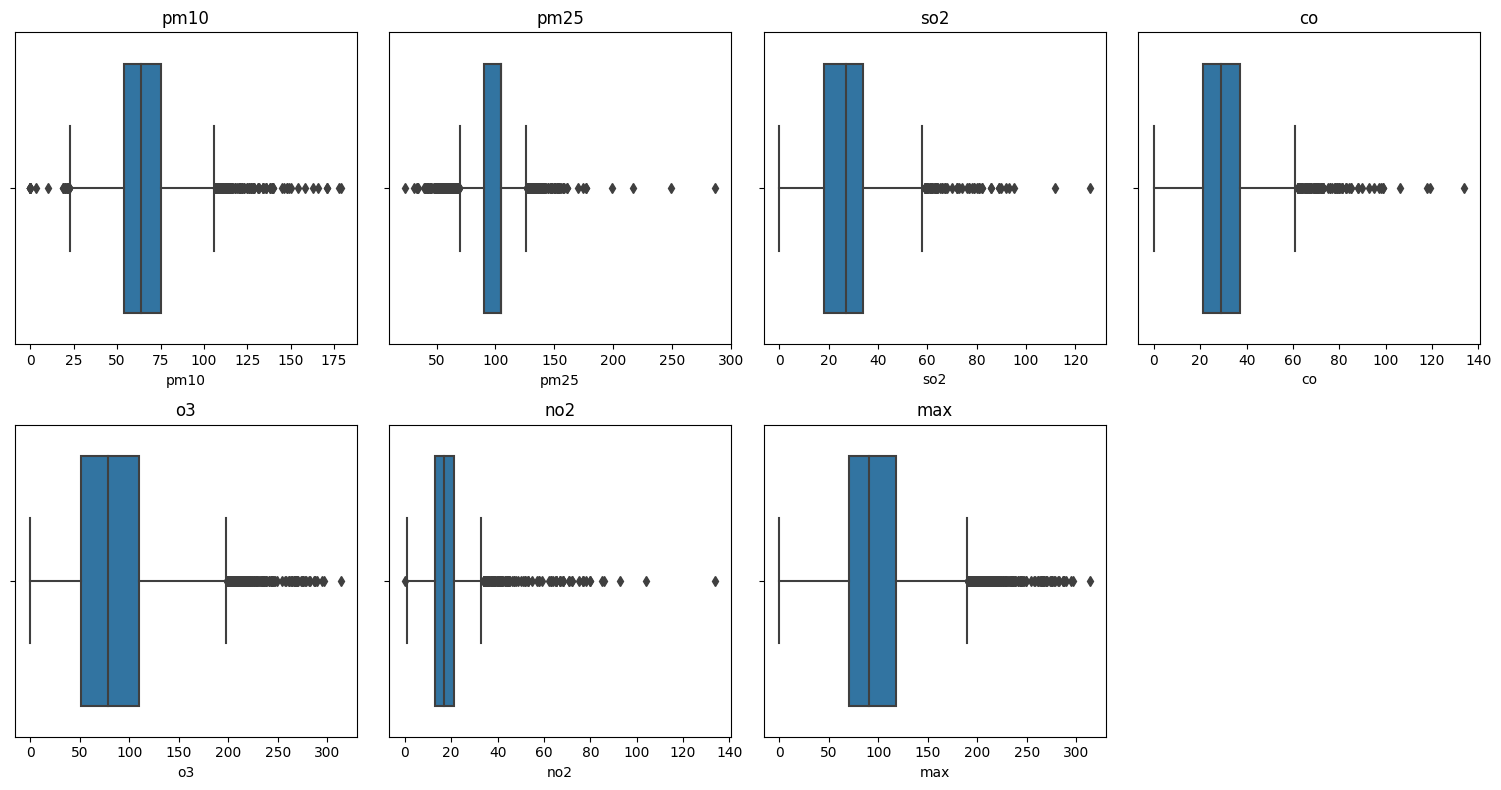

In [9]:
# Menampilkan boxplot dari fitur-fitur numerikal untuk mendeteksi outlier
num_features = df.select_dtypes(include=['number']).columns
num_plots = len(num_features)
rows = (num_plots // 4) + (num_plots % 4 > 0)
fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
# Menghapus baris dengan outlier
column_with_outlier = ["pm10", "pm25", "so2", "co", "o3", "no2", "max"]

Q1 = df[column_with_outlier].quantile(0.25)
Q3 = df[column_with_outlier].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[~((df[column_with_outlier] < lower_bound) | (df[column_with_outlier] > upper_bound)).any(axis=1)]
df.shape

(3599, 11)

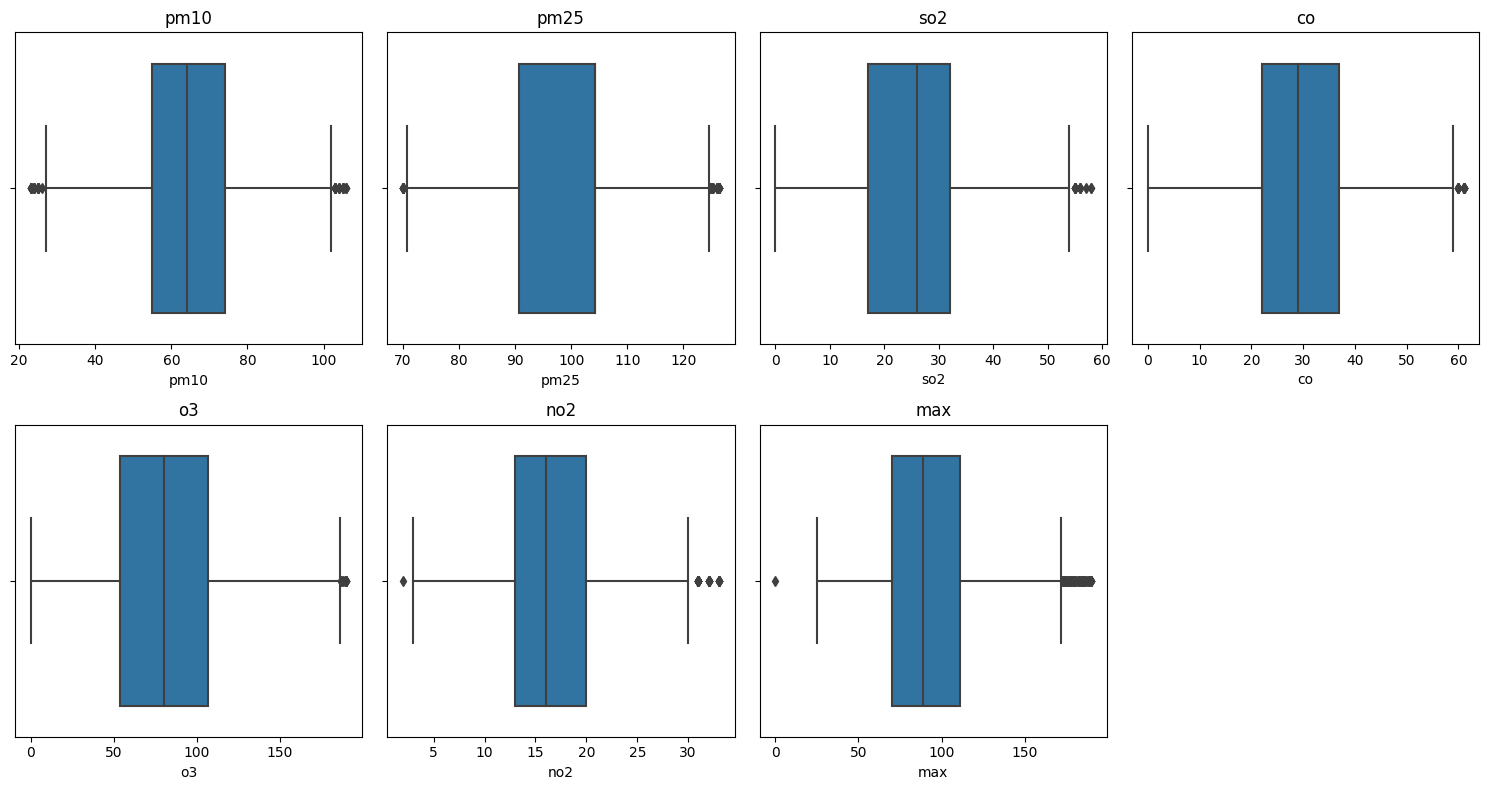

In [11]:
# Menampilkan ulang boxplot untuk mengecek apakah outlier sudah teratasi
num_features = df.select_dtypes(include=['number']).columns
num_plots = len(num_features)
rows = (num_plots // 4) + (num_plots % 4 > 0)
fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Univariate Analysis

In [12]:
numerical_features = ["pm10", "pm25", "so2", "co", "o3", "no2", "max"]
categorical_features = ["tanggal", "stasiun", "critical", "categori"]

### Categorical Features


Distribusi data untuk tanggal:
             jumlah sampel  persentase
tanggal                              
2010-01-02              1         0.0
2018-05-12              1         0.0
2018-01-11              1         0.0
2018-01-12              1         0.0
2018-01-13              1         0.0
...                   ...         ...
2014-04-16              1         0.0
2014-04-17              1         0.0
2014-04-18              1         0.0
2014-04-19              1         0.0
2023-11-29              1         0.0

[3599 rows x 2 columns]


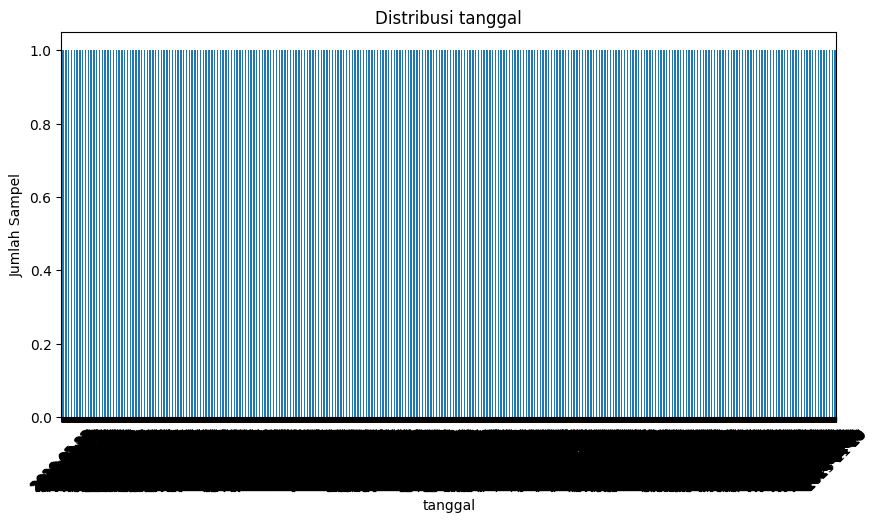


Distribusi data untuk stasiun:
                       jumlah sampel  persentase
stasiun                                        
DKI4 (Lubang Buaya)            1112        30.9
DKI3 (Jagakarsa)                781        21.7
DKI5 (Kebon Jeruk)              725        20.1
DKI2 (Kelapa Gading)            561        15.6
DKI1 (Bunderan HI)              420        11.7


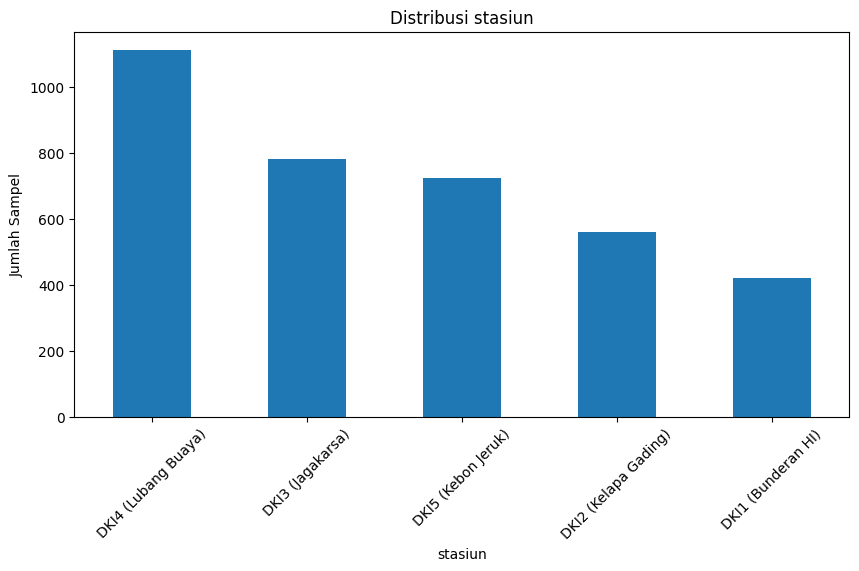


Distribusi data untuk critical:
           jumlah sampel  persentase
critical                           
O3                 2396        66.6
PM10                779        21.6
PM25                388        10.8
SO2                  20         0.6
CO                   16         0.4


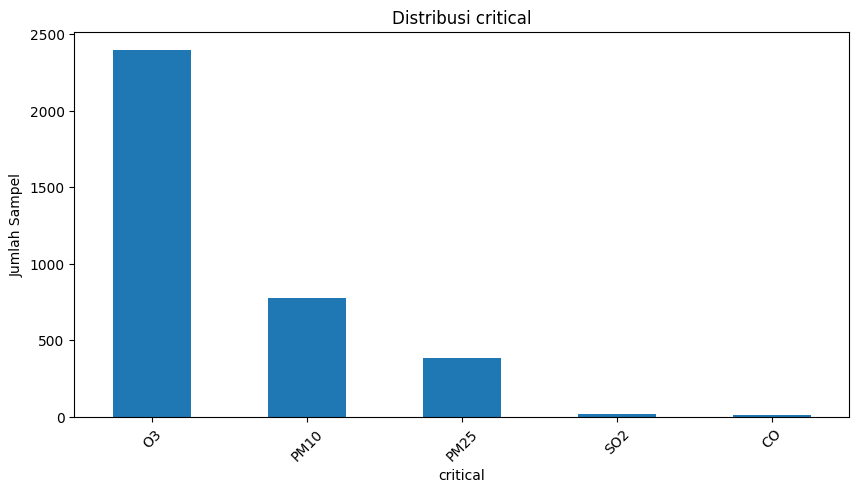


Distribusi data untuk categori:
                 jumlah sampel  persentase
categori                                 
SEDANG                   2135        59.3
TIDAK SEHAT              1234        34.3
BAIK                      229         6.4
TIDAK ADA DATA              1         0.0


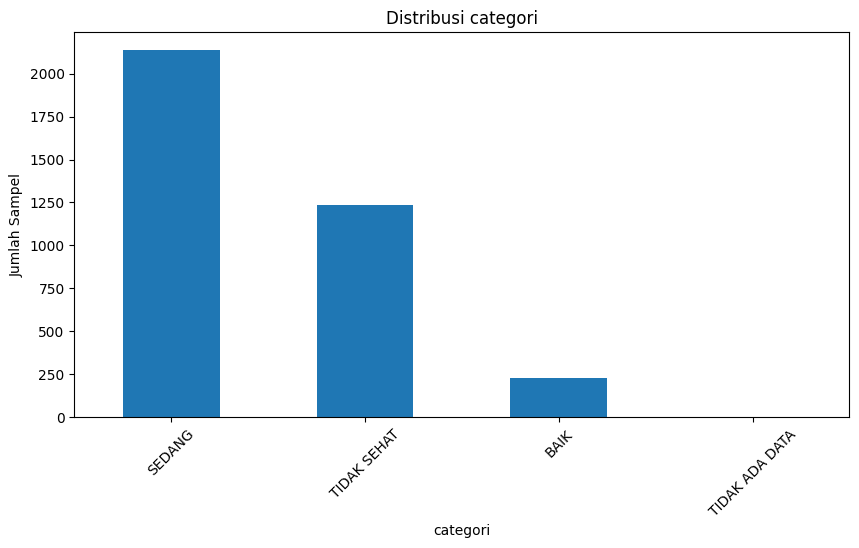

In [13]:
for feature in categorical_features:
    count = df[feature].value_counts()
    percent = 100 * df[feature].value_counts(normalize=True)

    df_summary = pd.DataFrame({'jumlah sampel': count, 'persentase': percent.round(1)})
    print(f"\nDistribusi data untuk {feature}:\n", df_summary)

    plt.figure(figsize=(10, 5))
    count.plot(kind='bar', title=f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Jumlah Sampel')
    plt.xticks(rotation=45)
    plt.show()

### Numerical Features

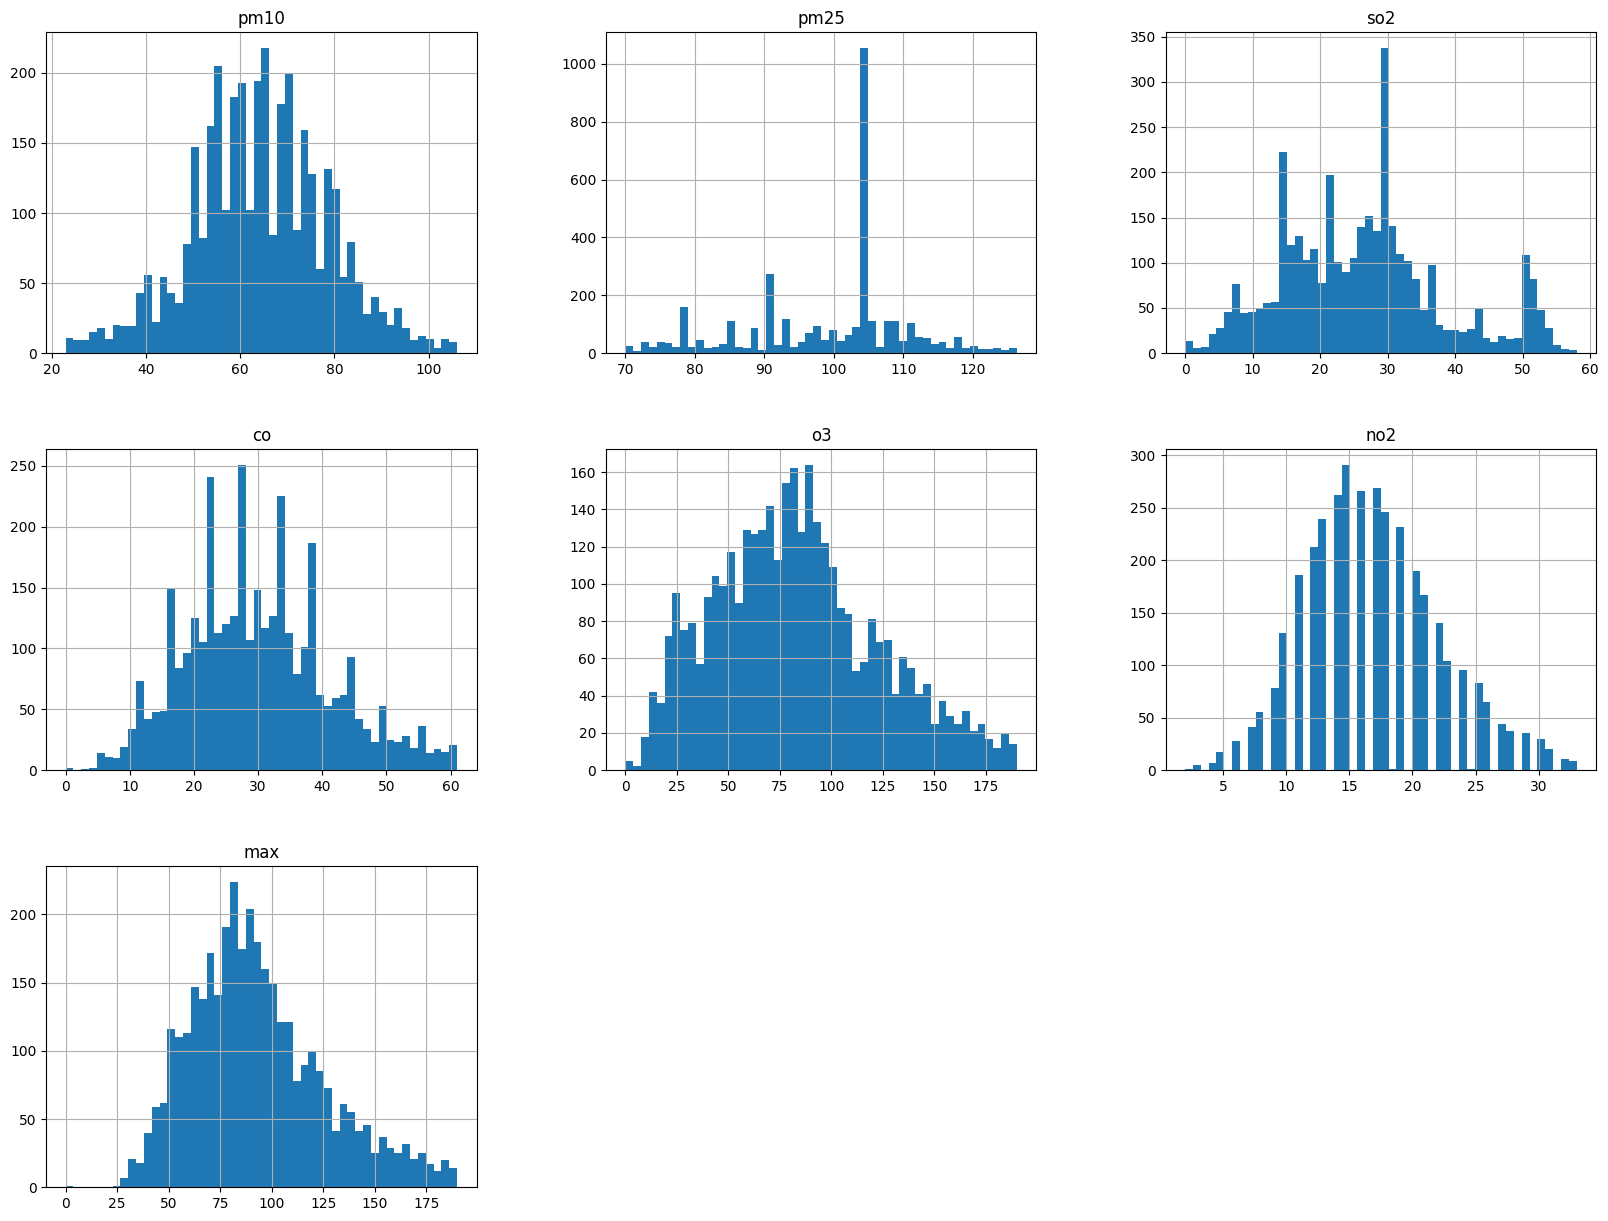

In [14]:
df.hist(bins=50, figsize=(20,15))
plt.show()

## Multivariate Analysis

### Categorical Features

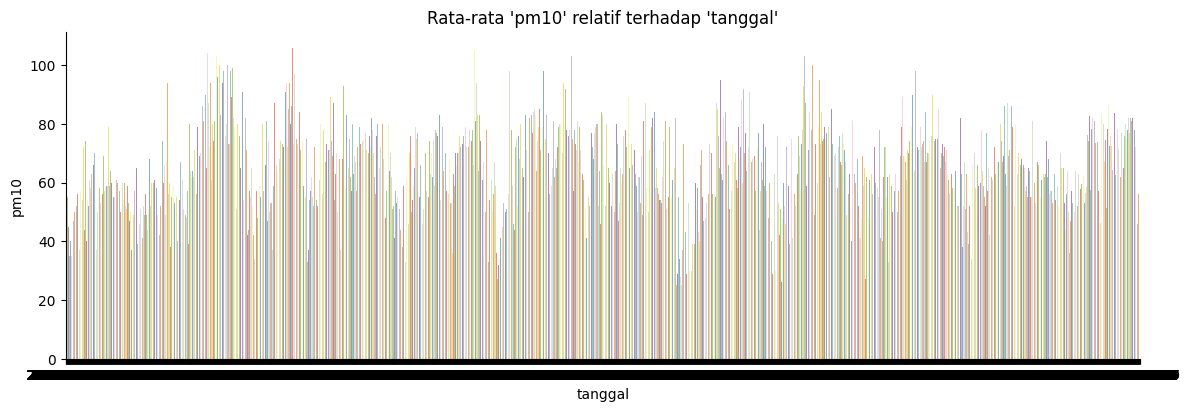

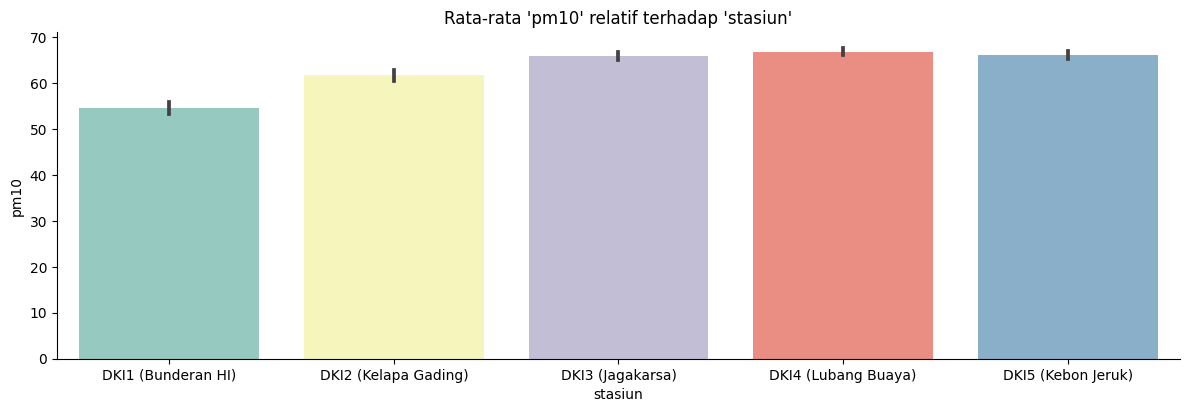

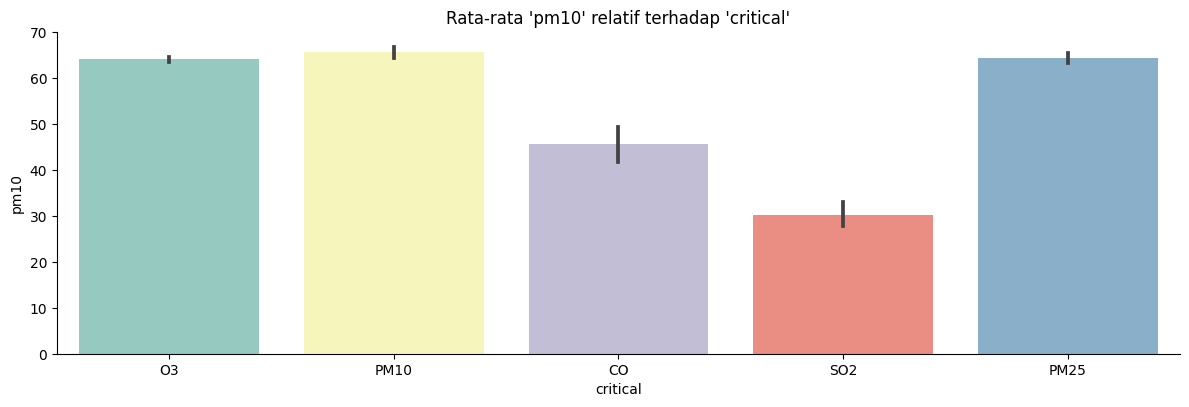

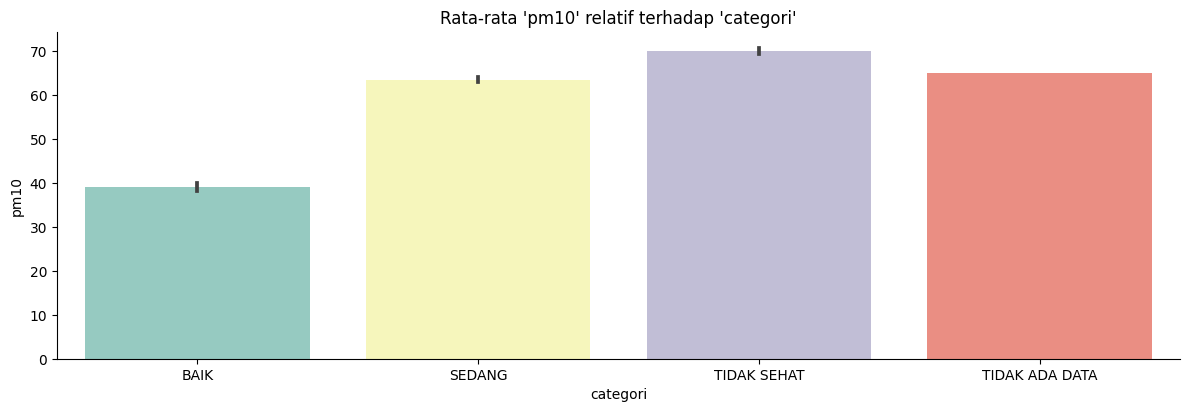

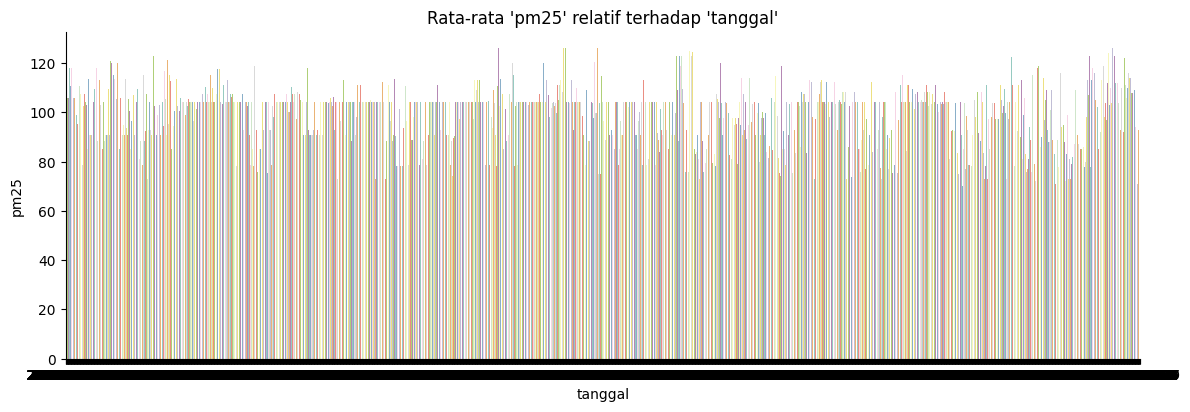

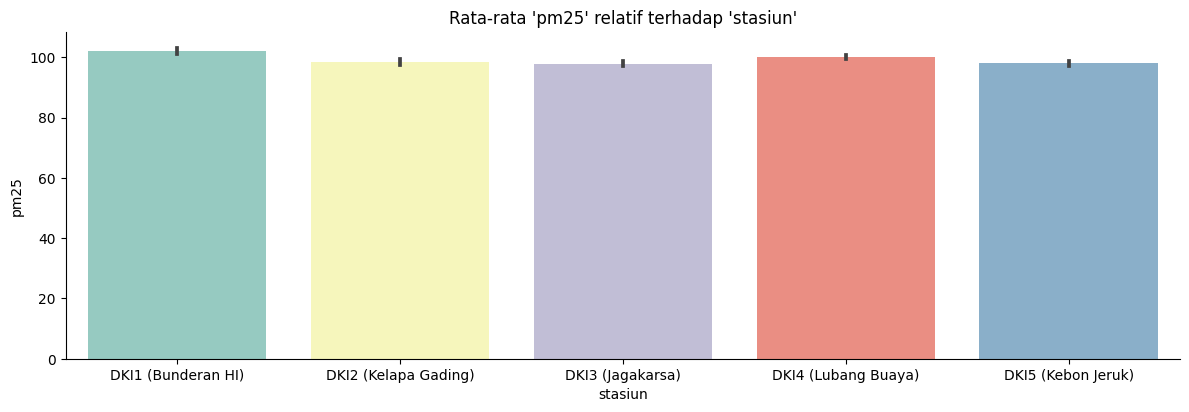

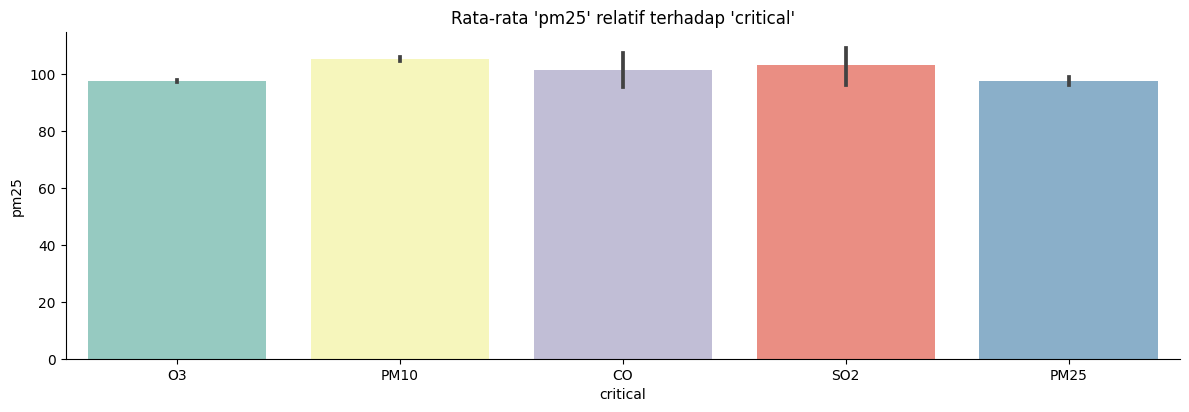

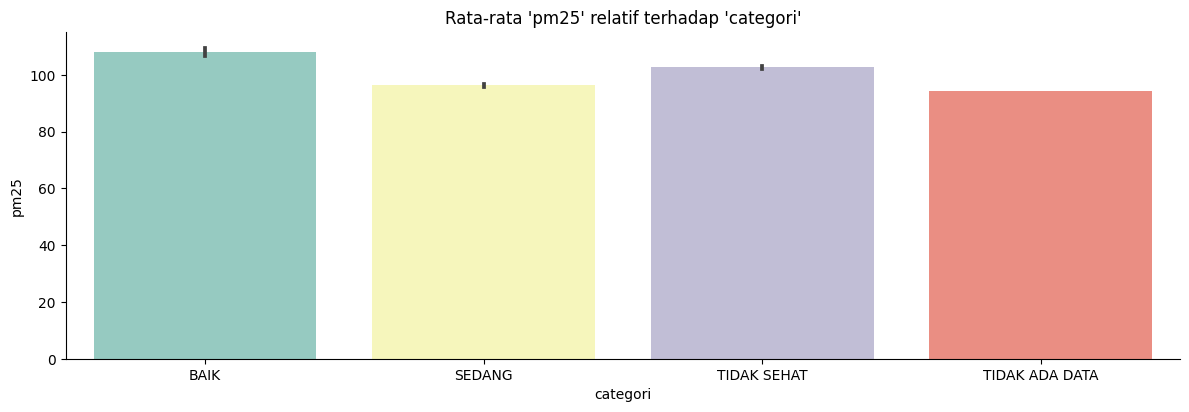

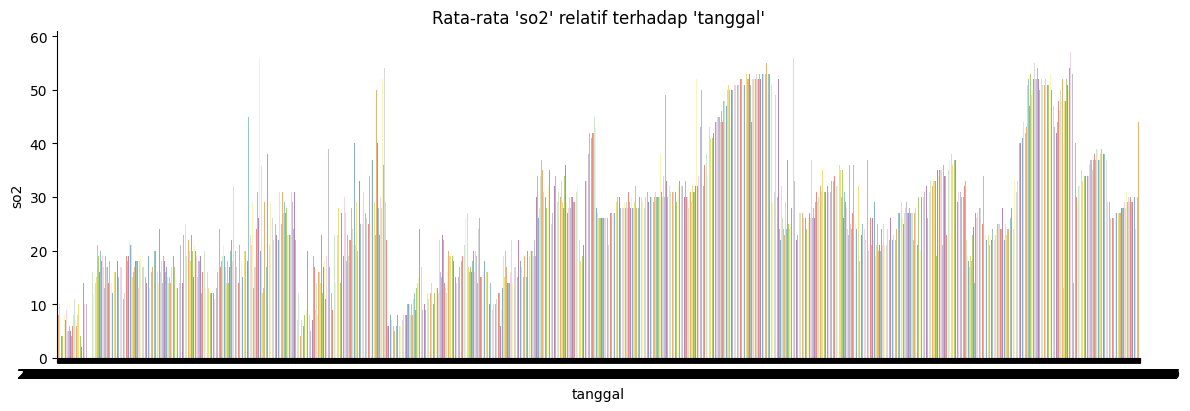

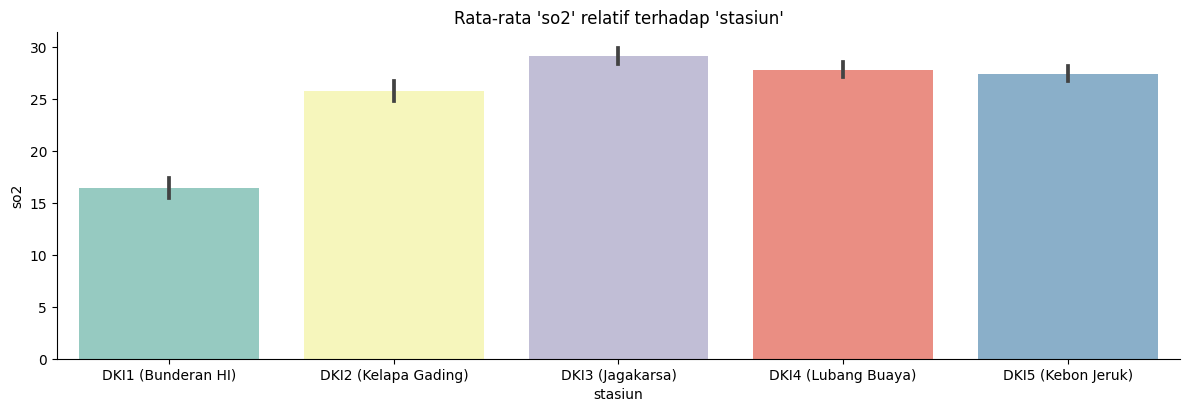

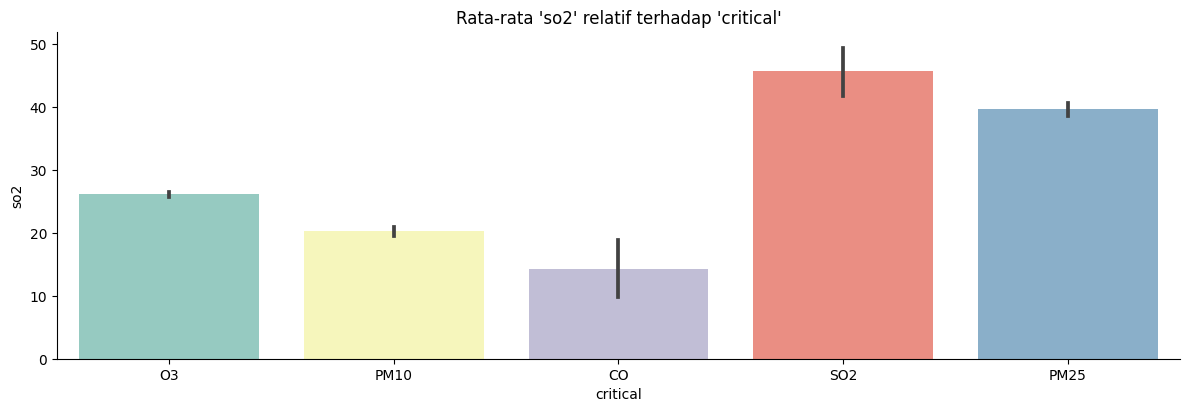

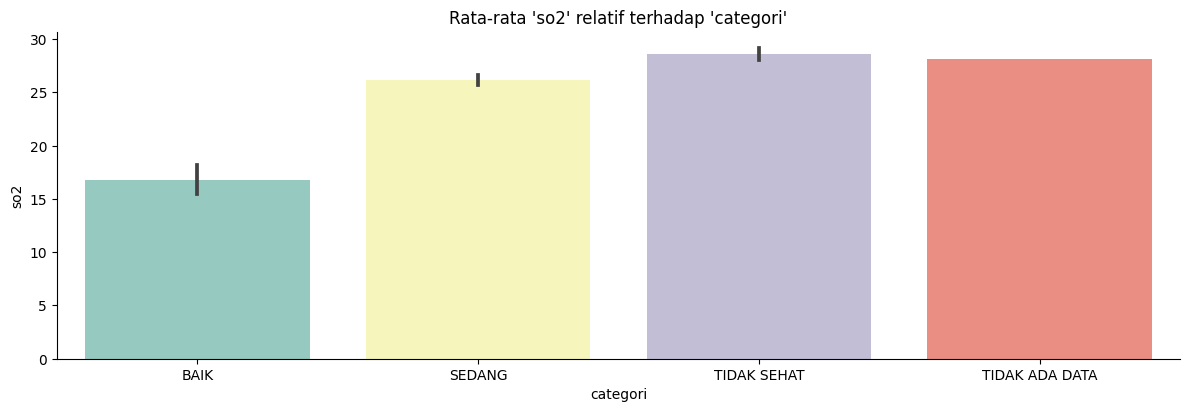

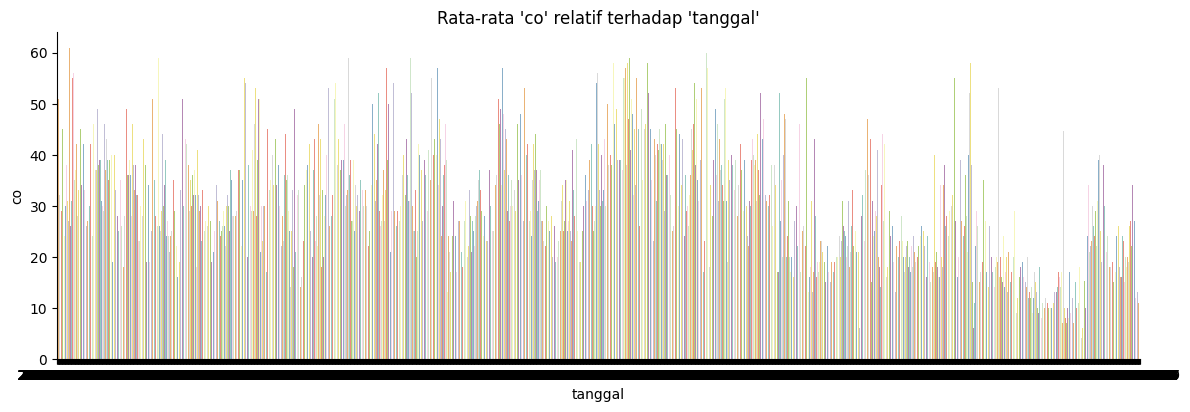

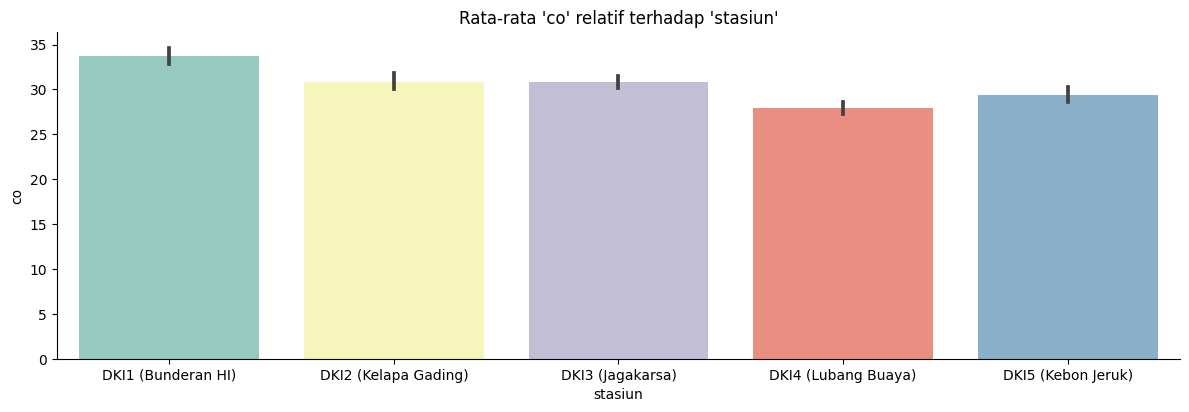

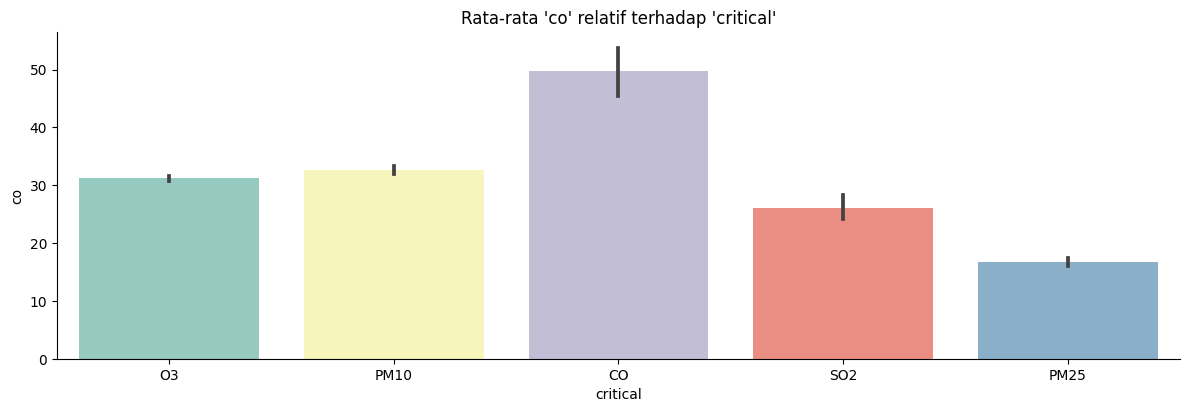

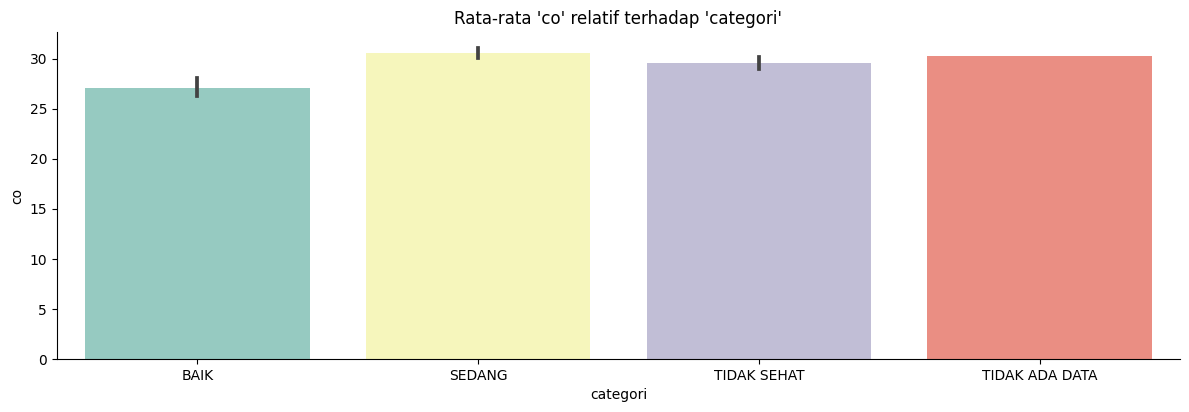

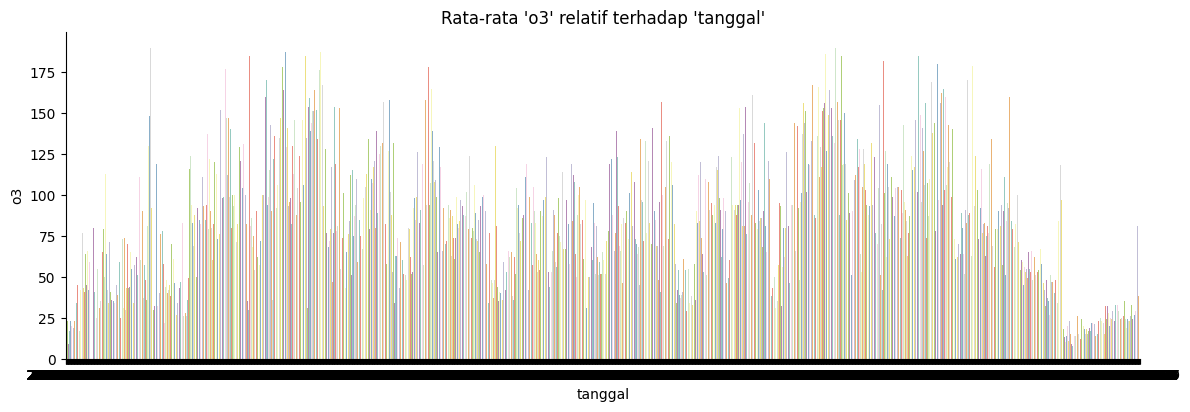

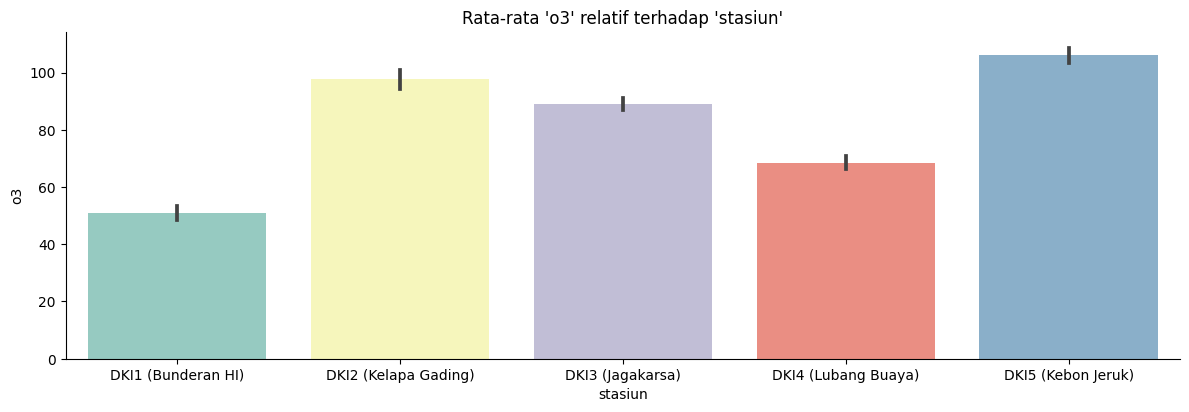

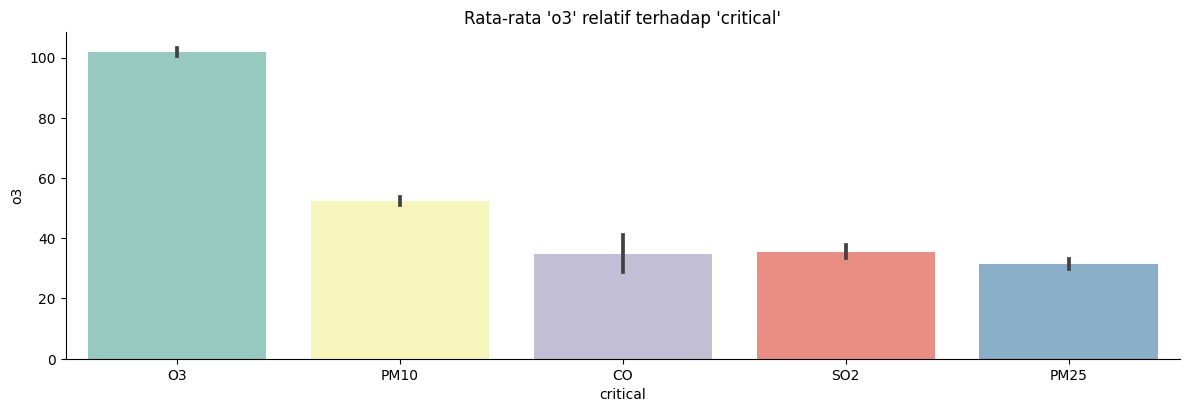

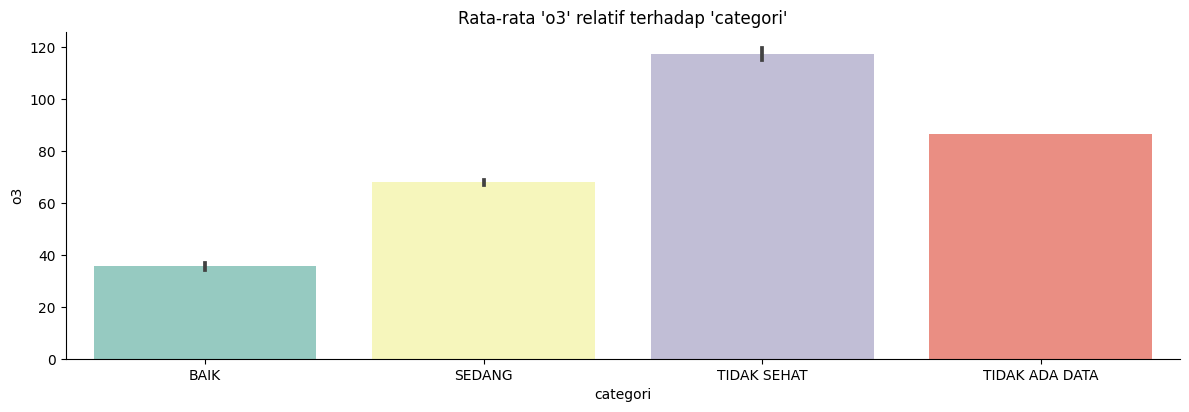

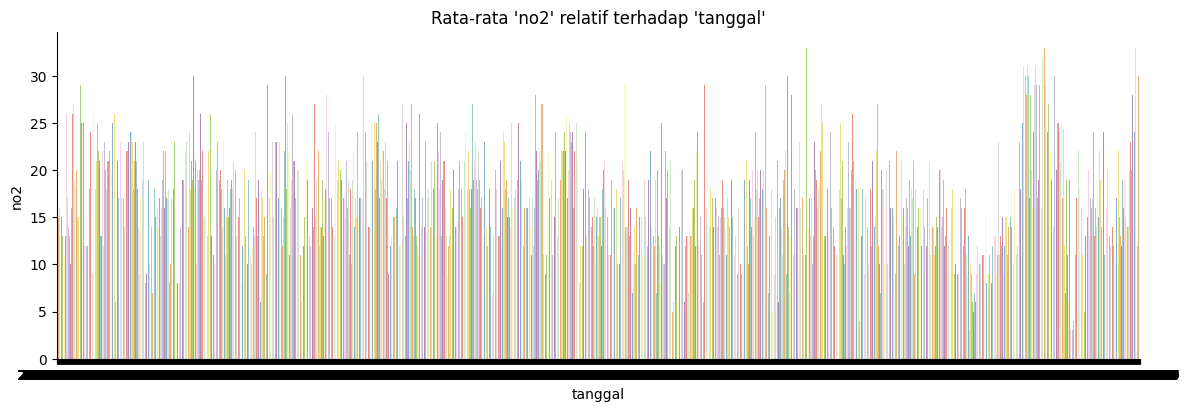

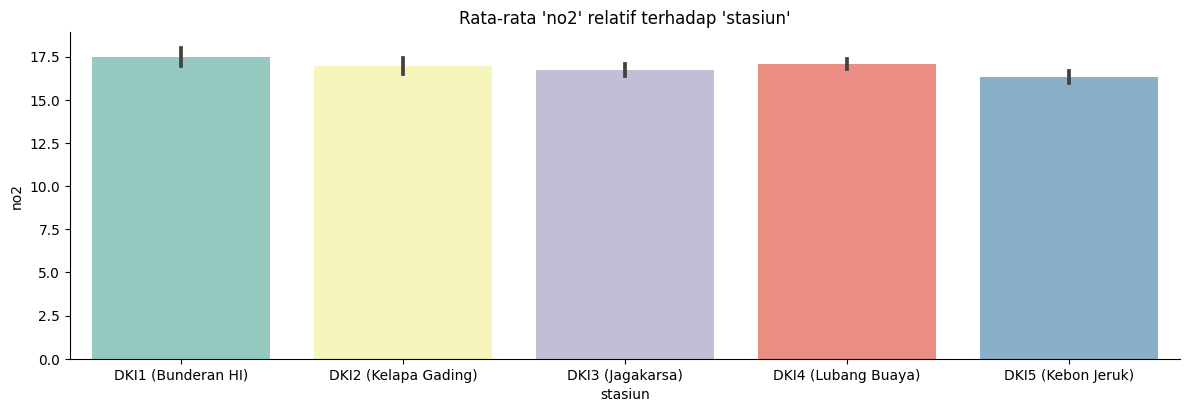

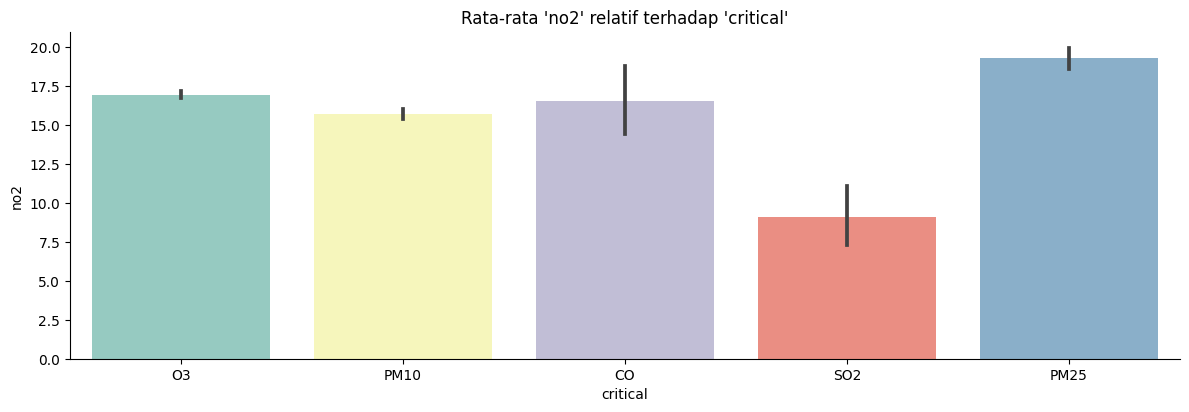

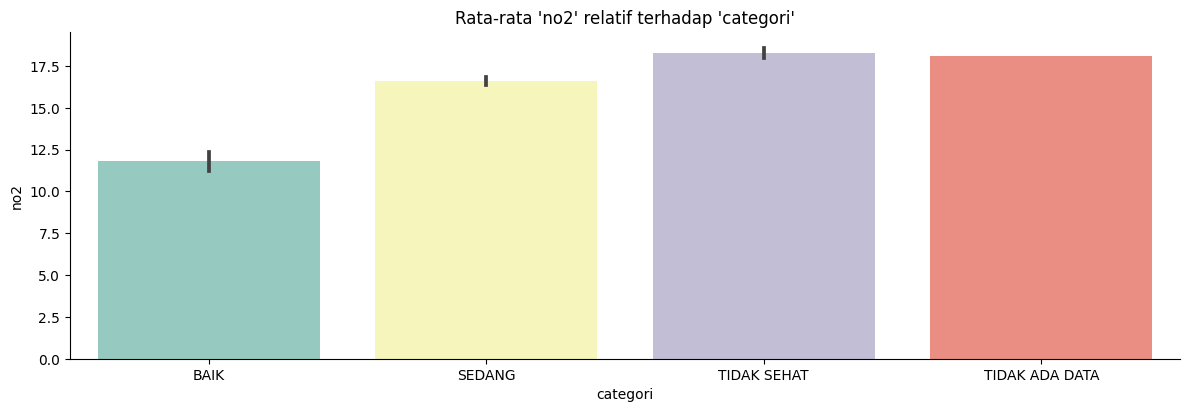

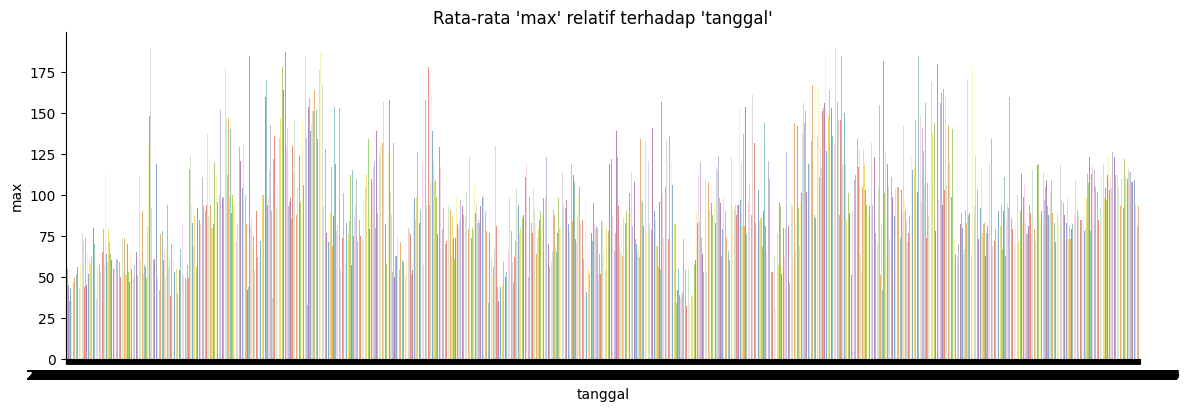

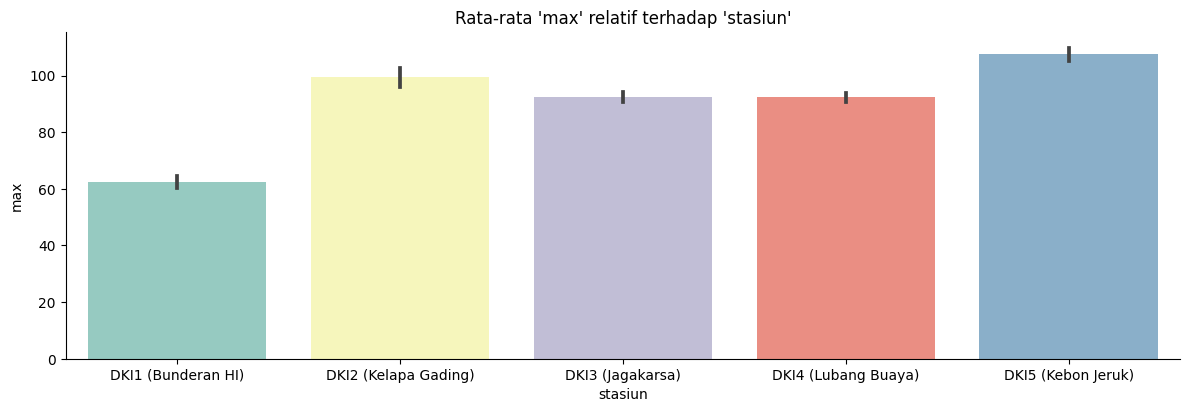

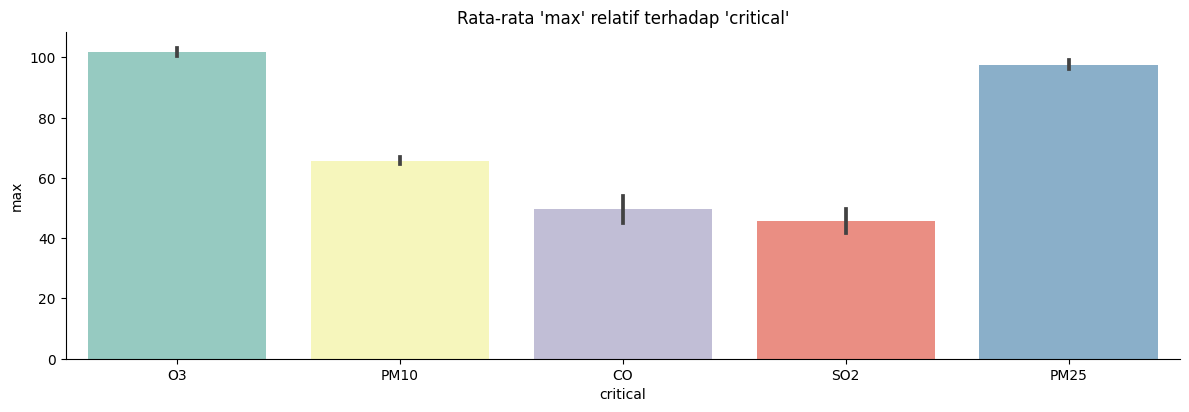

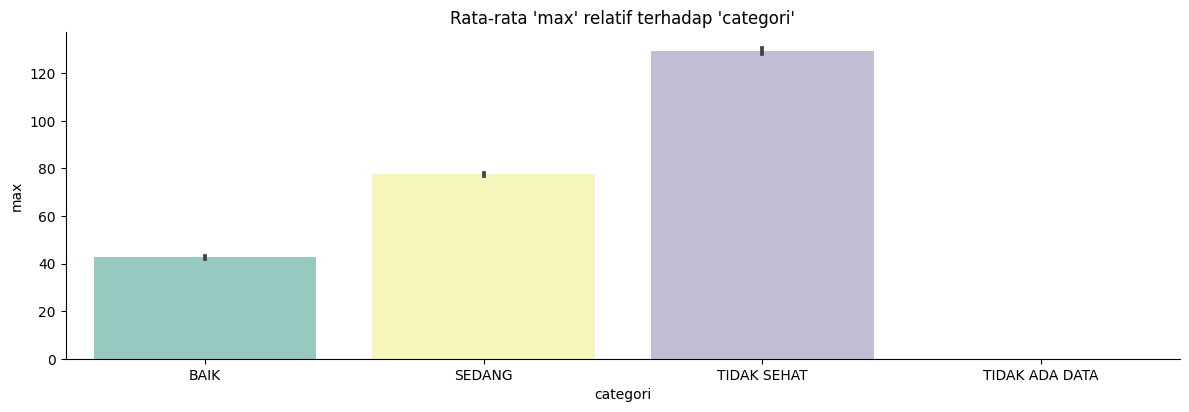

In [15]:
cat_features = df.select_dtypes(include='object').columns.to_list()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.to_list()

for num_col in num_features:
    for cat_col in cat_features:
        sns.catplot(x=cat_col, y=num_col, kind="bar", dodge=False, height=4, aspect=3, data=df, palette="Set3")
        plt.title(f"Rata-rata '{num_col}' relatif terhadap '{cat_col}'")
        plt.show()
